In [1]:
import mmexofast as mmexo
import os.path
from pathlib import Path
import numpy as np
from DC18_classes import TestDataSet

In [2]:
test_data = TestDataSet(lc_num=4)
files=[test_data.file_w149, test_data.file_z087]

coords = '18:01:12.90 -27:25:37.2'
base_dir = Path('notebook_output')

In [ ]:
fitter = mmexo.mmexofast.MMEXOFASTFitter(
    files=files, coords=coords, fit_type='binary_lens', finite_source_point_lens=True, renormalize_errors=True, verbose=True, 
    output_config =mmexo.OutputConfig(**{'output_dir': base_dir, 'save_plots': True, 'save_grid_results': True}),
    log_file='notebook_output/OB140221_example_00.log')

In [4]:
fitter.run_event_search()

Saved EF grid plot to notebook_output/ef_grid.pdf.
Best EF grid point: {'t_0': 2460024.2772946307, 't_eff': 9.988721231519582, 'j': 2, 'chi2': -41716.45353407352}


In [5]:
fitter.estimate_point_lens_parameters()

Estimated point-lens params: {'t_0': 2460024.2772946307, 't_E': 10.0, 'u_0': 1.0}


In [6]:
fitter.fit_static_point_source_point_lens()

fixxxxxxxx
new value: [2460024.2772946307, 10.0, 1.0, 0.5354327657793708, 1.899703223825772, 0.18137759941824608, 0.4804223858048246]
fluxes: [[array([0.53543277]), 1.899703223825772], [array([0.1813776]), 0.4804223858048246]]
model:     t_0 (HJD)       u_0    t_E (d) 
2460024.27729  1.000000    10.0000 
coords: 18:01:12.90 -27:25:37.20
default magnification method: point_source
residuals [ 0.01708949  0.00761951  0.04511939 ...  0.00332248  0.00170515
 -0.00033625]
res min/max -0.09458452700432396 0.27225992668153776 0.27225992668153776
chi2 47149.021886392584
df [[-3.22100643e-12 -3.22110745e-12 -3.22120849e-12 ...  1.71257309e-04
   1.61736053e-04  1.52996704e-04]
 [ 5.40411386e-10  5.40424945e-10  5.40438506e-10 ...  5.76181983e-04
   5.52293383e-04  5.29994176e-04]
 [-1.91981196e-13 -1.91988422e-13 -1.91995648e-13 ... -5.09024347e-04
  -4.73635055e-04 -4.41665071e-04]
 ...
 [ 1.00000000e+00  1.00000000e+00  1.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0

Static PSPL: {'t_0': 2460024.151943596, 't_E': 5.642258623343874, 'u_0': 2.2215421900722667, 'chi2': 46878.61664710115}
    sigmas:  [0.045380521206760074, 2.8041534417367813, 1.406437527046394, 7.744031808972607, 7.7440103176962705, 2.6234128668005328, 2.6234059947748083]


In [7]:
fitter.fit_static_finite_source_point_lens() #somthing is not right with this finite source fit

/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/mateusz/mulens/MulensModel/source/MulensModel/magnificationcurve.py:195: UserWarning: A finite source parameter (rho or t_star) is set and no finite-source method is set.
For possible magnification methods see
/home/mateusz/mulens/MulensModel/source/MulensModel/documents/magnification_methods.pdf
or
https://github.com/rpoleski/MulensModel/blob/master/documents/magnification_methods.pdf
  warnings.warn(msg, UserWarning)
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
Finite-source point-lens fitter failed. Mostlikely due to weak finie-source effect signal 
---- Event I

In [14]:
fitter.all_fit_results

<AllFitResults:
  'PSPL static': <FitRecord(lens=point, source=point, parallax=none, motion=none; params={t_0=2460024.151943596, t_E=5.642258623343874, u_0=2.2215421900722667}, sigmas={t_0=0.045380521206760074, t_E=2.8041534417367813, u_0=1.406437527046394}; full=True, fixed=False, complete=True, renorm=True, n_params=3)>
>

In [15]:
fitter.fit_parallax()

Seeding u0+ from static model with pi_E = 0.
Parallax fit: {'t_0': 2460024.128851405, 't_E': 5.614650386507052, 'u_0': 3.1045959835601247, 'pi_E_N': -0.8016564156484624, 'pi_E_E': 0.002578722252101962, 'chi2': 46851.21302018265}
      sigmas: [5.670775144605375, 16.36762580403295, 63.00647637518025, 65.41505078876641, 0.49712994055393206, 19.5483510499125, 19.548349245975622, 6.620726487108422, 6.620726015048845]
Parallax u0+: chi2=46851.21
Seeding u0- from static model with pi_E = 0.
Parallax fit: {'t_0': 2460024.128851405, 't_E': 5.614650386507052, 'u_0': 3.1045959835601247, 'pi_E_N': -0.8016564156484624, 'pi_E_E': 0.002578722252101962, 'chi2': 46851.21302018265}
      sigmas: [5.670775144605375, 16.36762580403295, 63.00647637518025, 65.41505078876641, 0.49712994055393206, 19.5483510499125, 19.548349245975622, 6.620726487108422, 6.620726015048845]
Parallax u0-: chi2=46851.21


In [16]:
fitter.all_fit_results

<AllFitResults:
  'PSPL static': <FitRecord(lens=point, source=point, parallax=none, motion=none; params={t_0=2460024.151943596, t_E=5.642258623343874, u_0=2.2215421900722667}, sigmas={t_0=0.045380521206760074, t_E=2.8041534417367813, u_0=1.406437527046394}; full=True, fixed=False, complete=True, renorm=True, n_params=3)>
  'PSPL par u0+': <FitRecord(lens=point, source=point, parallax=u0+, motion=none; params={t_0=2460024.128851405, t_E=5.614650386507052, u_0=3.1045959835601247, pi_E_N=-0.8016564156484624, pi_E_E=0.002578722252101962}, sigmas={t_0=5.670775144605375, t_E=16.36762580403295, u_0=63.00647637518025, pi_E_N=65.41505078876641, pi_E_E=0.49712994055393206}; full=True, fixed=False, complete=True, renorm=True, n_params=5)>
  'PSPL par u0-': <FitRecord(lens=point, source=point, parallax=u0-, motion=none; params={t_0=2460024.128851405, t_E=5.614650386507052, u_0=3.1045959835601247, pi_E_N=-0.8016564156484624, pi_E_E=0.002578722252101962}, sigmas={t_0=5.670775144605375, t_E=16.36762

In [18]:
fitter.compute_point_lens_residuals()

Calculating residuals relative to PSPL static


In [19]:
fitter.run_anomaly_search()

Saved AF grid plot to notebook_output/ef_grid.pdf.
Best AF grid point: {'t_0': 2460017.5887943334, 't_eff': 0.75, 'j': 2.0, 'chi2': 395.7606207790801, 'dchi2_zero': 6346.91833768755, 'dchi2_flat': 4217.45985313257}


In [23]:
fitter.get_anomaly_light_curve_parameters()

Estimated anomaly params: {'t_0': 2460024.151943596, 't_E': 5.642258623343874, 'u_0': 2.2215421900722667, 'dmag': -0.09309094443958088, 'dt': 1.1440299996174872, 't_pl': 2460017.586961}


In [24]:
fitter.classify_anomaly()

Anomaly classified as anomaly_type = wide


/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
Estimated binary params (WidePlanet): {'t_0': 2460024.151943596,

WidePlanet
{'t_0': 2460024.151943596, 'u_0': 2.2215421900722667, 't_E': 5.642258623343874, 's': 2.9093919755058764, 'alpha': 63.04718654909148, 'rho': 0.14790702510415862, 'q': 0.0005566974687494842}
[2460006.146661004, 'VBBL', 2460029.794202219]
WidePlanet_alt
{'t_0': 2460024.151943596, 'u_0': 2.2215421900722667, 't_E': 5.642258623343874, 's': 2.80698541063101, 'alpha': 62.356593051958946, 'rho': 0.0506902499508025, 'q': 0.0001185162016136612}
[2460006.146661004, 'VBBL', 2460029.794202219]


/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))


CloseUpperBinary
{'t_0': 2460024.151943596, 'u_0': 2.2215421900722667, 't_E': 5.642258623343874, 's': 0.3527120039522208, 'q': 0.023703417690389306, 'rho': 0.09788980314969249, 'alpha': 223.21105571332419}
[2460006.146661004, 'VBBL', 2460029.794202219]


/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))


...

/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))


CloseLowerBinary
{'t_0': 2460024.151943596, 'u_0': 2.2215421900722667, 't_E': 5.642258623343874, 's': 0.34778502369704895, 'q': 0.013983049773912983, 'rho': 0.08036729619828993, 'alpha': -102.74808363612715}
[2460006.146661004, 'VBBL', 2460029.794202219]


/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))


CloseLowerBinary_alt
{'t_0': 2460024.151943596, 'u_0': 2.2215421900722667, 't_E': 5.642258623343874, 's': 0.3542784663305679, 'q': 0.004, 'rho': 0.001, 'alpha': -109.95117305017214}
[2460006.146661004, 'VBBL', 2460029.794202219]


/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))


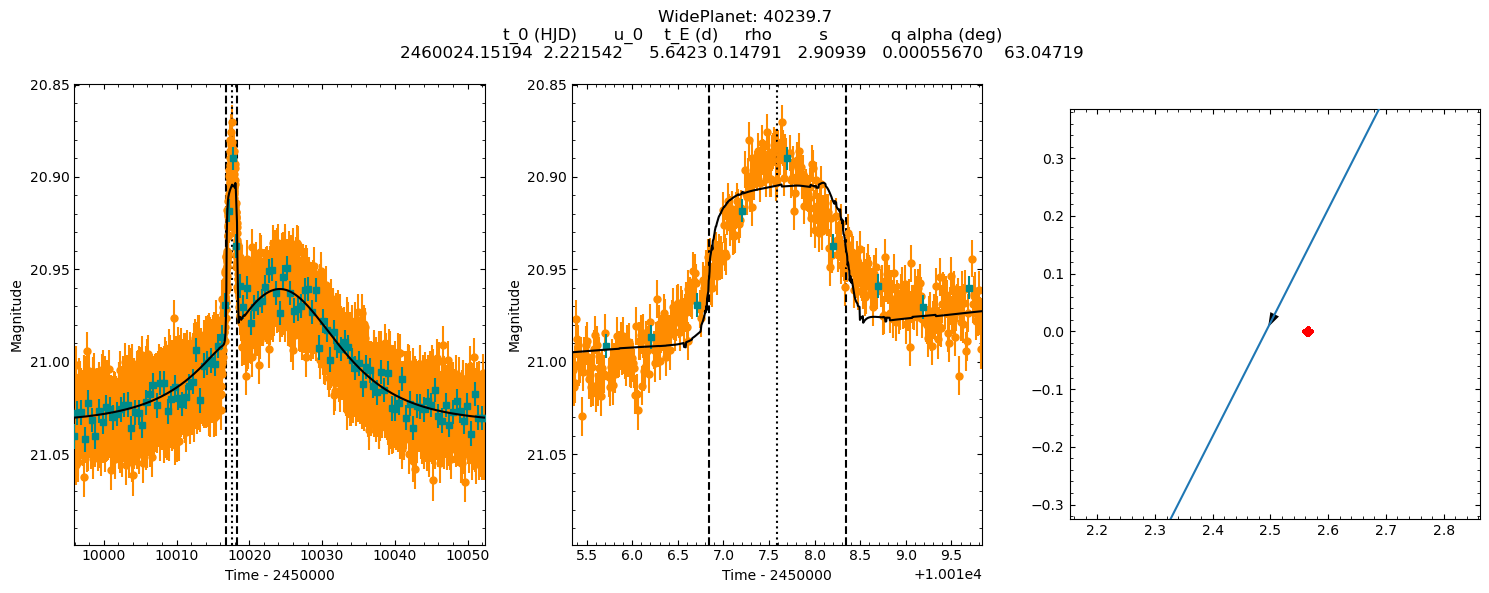

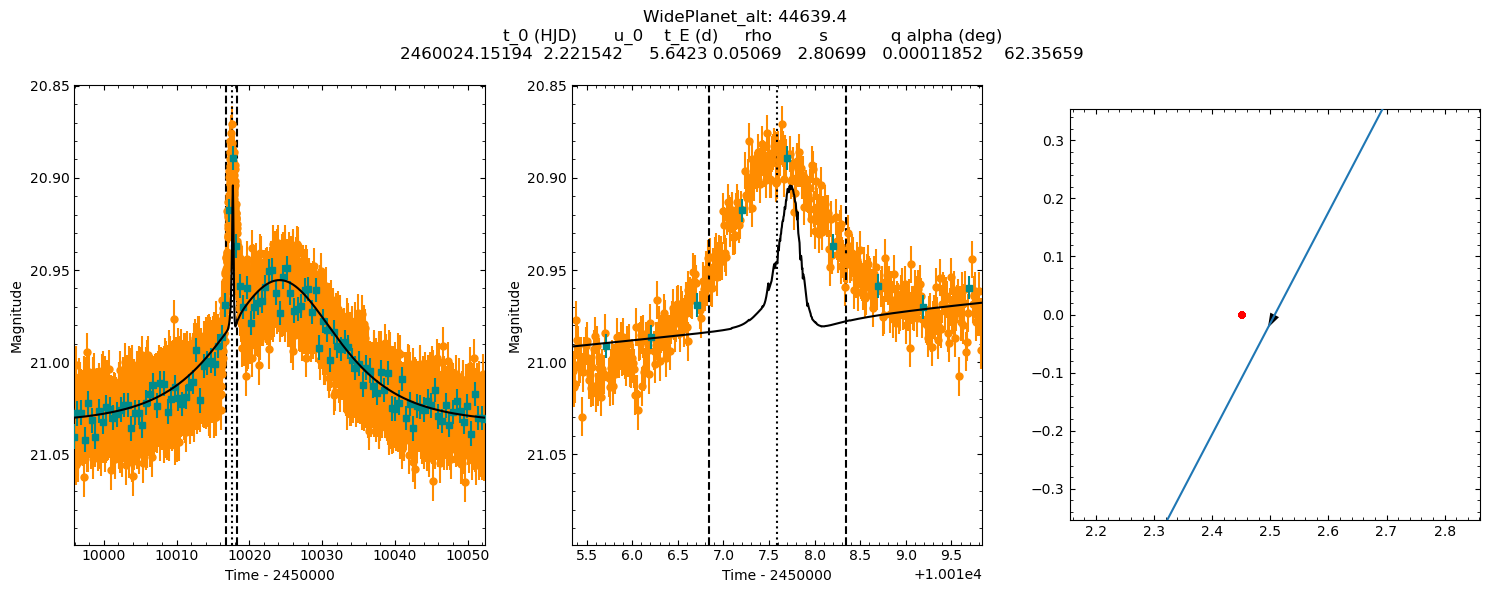

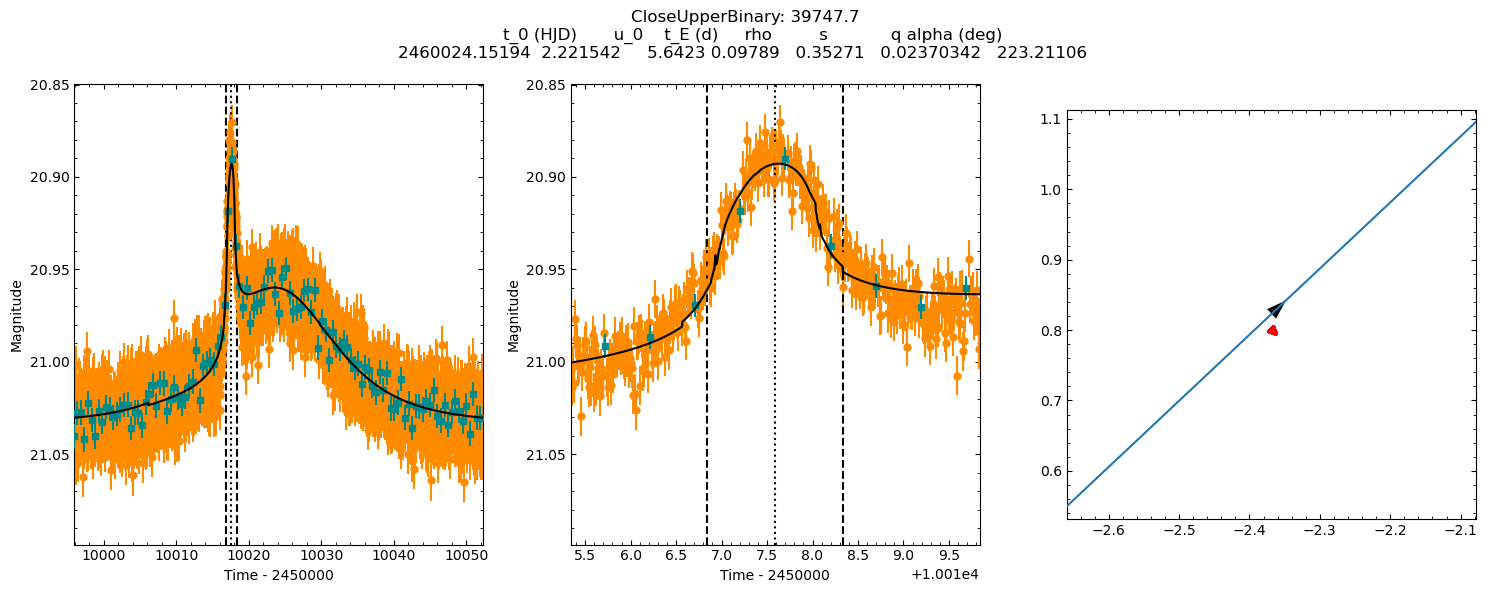

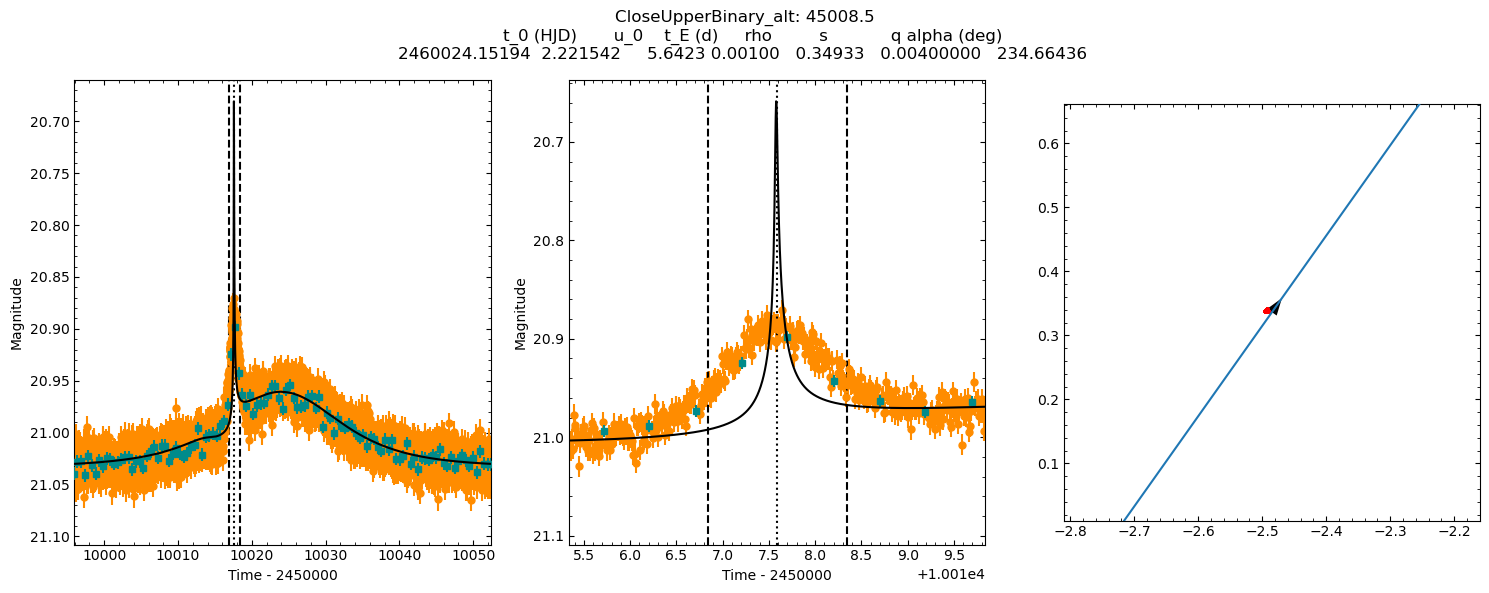

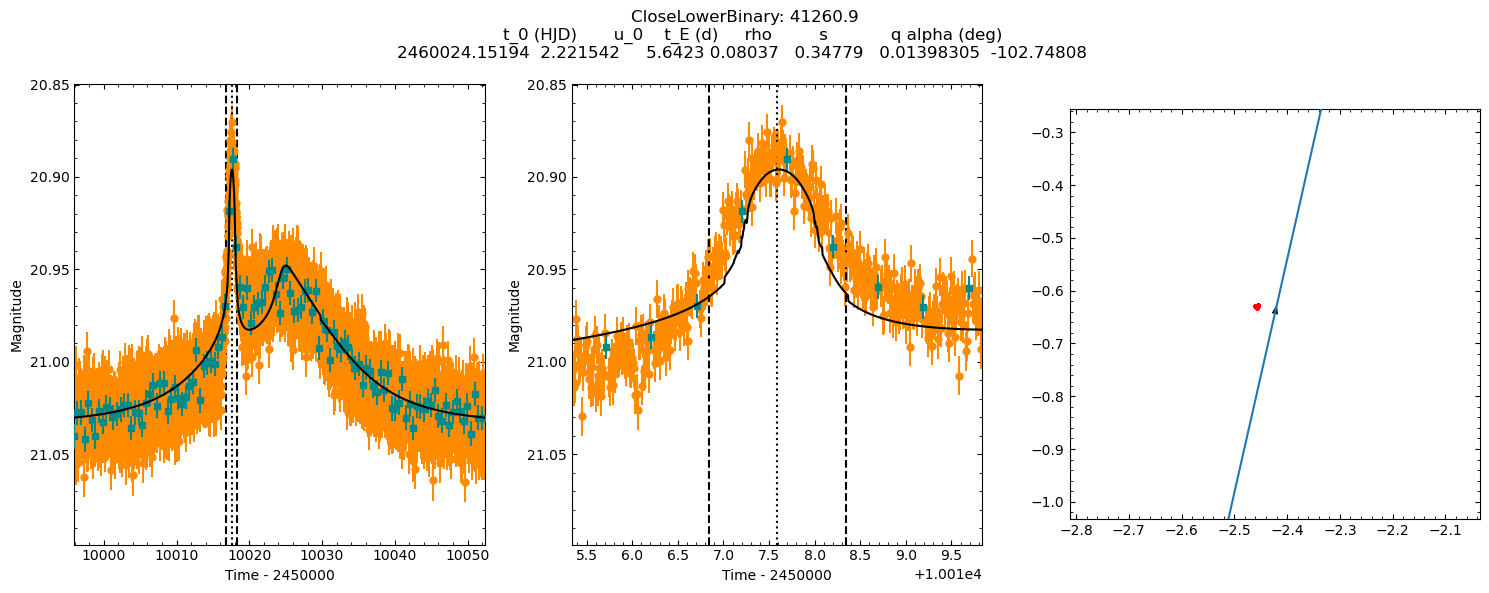

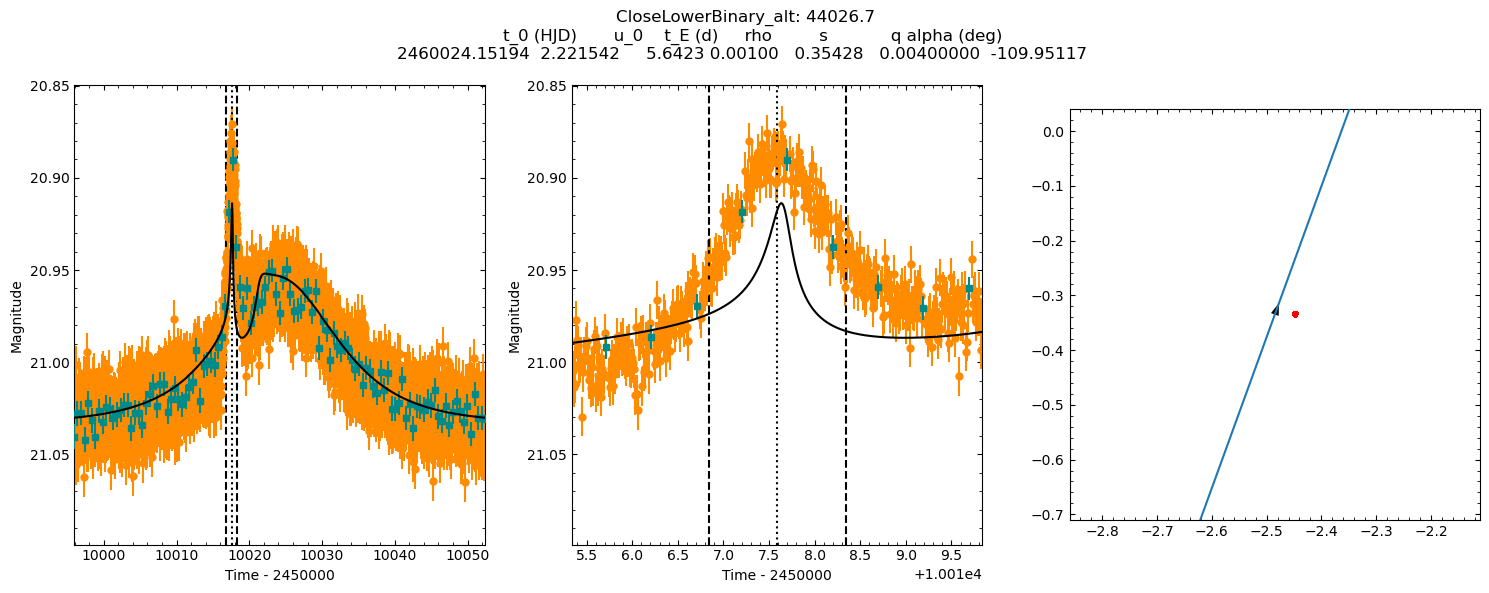

In [27]:
fitter.estimate_binary_lens_parameters()

In [ ]:
fitter.fit_binary_lens_models()

PL chi2: 46878.6, N_good: 39438
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/mateusz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
WidePlanet initial chi2: 40239.7
initial sigmas: {'t_0': 1e-05, 'u_0': 0.002221542190072267, 't_E': 0.005642258623343875, 'log_rho': 0.0001, 'log_s': 0.0001, 'log_q': 0.0001, 'alpha': 0.0001}


In [ ]:
fitter.fit_parallax()

In [ ]:
fitter.renormalize_datasets()